# 🤖 Pure ML Classification Pipeline — EEG Epilepsy Detection
> **Fully self-contained — run cell by cell from top to bottom**  
> **Input:** Guinea-Bissau EEG dataset (auto-downloaded)  
> **Output:** Trained model, benchmark table, confusion matrices, ROC, SHAP

### Classifiers Benchmarked
| # | Model | Type |
|---|---|---|
| 1 | Logistic Regression | Linear |
| 2 | Ridge Classifier | Linear |
| 3 | SVM (RBF kernel) | Kernel |
| 4 | Random Forest | Ensemble (bagging) |
| 5 | Extra Trees | Ensemble (bagging) |
| 6 | Gradient Boosting | Ensemble (boosting) |
| 7 | XGBoost | Ensemble (boosting) |
| 8 | Voting Ensemble | Meta |


## 📦 Step 1 — Install & Imports

In [1]:
!pip install xgboost imbalanced-learn shap scikit-learn mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os, json, joblib
warnings.filterwarnings('ignore')

import mne
from scipy import signal, stats

from sklearn.linear_model  import LogisticRegression, RidgeClassifier
from sklearn.svm           import SVC
from sklearn.ensemble      import (RandomForestClassifier, ExtraTreesClassifier,
                                    GradientBoostingClassifier, VotingClassifier)
from xgboost               import XGBClassifier

from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, RobustScaler
from sklearn.decomposition     import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection   import (GroupKFold, GridSearchCV,
                                         cross_validate, cross_val_predict)
from sklearn.metrics           import (classification_report, confusion_matrix,
                                         ConfusionMatrixDisplay, roc_auc_score,
                                         roc_curve, precision_recall_curve,
                                         average_precision_score,
                                         balanced_accuracy_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline

try:
    import shap; SHAP_OK = True
except: SHAP_OK = False

SEED = 42
np.random.seed(SEED)
print('✅ All imports OK')

✅ All imports OK


## 📂 Step 2 — Load EEG Data

> ⚠️ **Always run this cell** — it defines `data`, `label`, `group`, and `subject_meta`.
> Downloads ~200MB on first run; cached afterwards.

In [3]:
# ── Download dataset ────────────────────────────────────────────────────────
import os
from zipfile import ZipFile

if not os.path.exists('EEGs_Guinea-Bissau'):
    print('Downloading dataset...')
    os.system('wget -q https://zenodo.org/record/1252141/files/EEGs_Guinea-Bissau.zip')
    ZipFile('EEGs_Guinea-Bissau.zip').extractall()
    print('✅ Downloaded & extracted')
else:
    print('✅ Dataset already present')

meta_df = pd.read_csv(
    'https://zenodo.org/record/1252141/files/metadata_guineabissau.csv')
EP_ids  = meta_df['subject.id'][meta_df['Group']=='Epilepsy'].values
CT_ids  = meta_df['subject.id'][meta_df['Group']=='Control'].values
print(f'Subjects — Epilepsy: {len(EP_ids)} | Control: {len(CT_ids)}')

✅ Downloaded & extracted
Subjects — Epilepsy: 51 | Control: 46


In [4]:
%%capture
# ── Preprocessing: filter → epoch ───────────────────────────────────────────
def df_to_epochs(df, sfreq=128):
    info = mne.create_info(
        list(df.columns), ch_types=['eeg']*len(df.columns), sfreq=sfreq)
    info.set_montage('standard_1020')
    raw = mne.io.RawArray(df.T, info)
    raw.set_eeg_reference()
    raw.filter(l_freq=0.5, h_freq=45)
    return mne.make_fixed_length_epochs(
        raw, duration=5, overlap=1).drop_bad()

all_ep, all_lbl, all_grp = [], [], []
subject_meta = []
sid_counter  = 0

for ids, lbl_val, grp_name in [(EP_ids,0,'Epilepsy'),(CT_ids,1,'Control')]:
    for sid in ids:
        try:
            df = pd.read_csv(
                f'EEGs_Guinea-Bissau/signal-{sid}.csv.gz',
                compression='gzip').iloc[:, 1:15]
            ep = df_to_epochs(df)
            n  = len(ep)
            all_ep.append(ep)
            all_lbl.append(np.full(n, lbl_val))
            all_grp.append(np.full(n, sid_counter))
            subject_meta.append({'subject_id': sid, 'group_idx': sid_counter,
                                   'true_label': lbl_val, 'group_name': grp_name,
                                   'n_epochs': n})
            sid_counter += 1
        except Exception as e:
            print(f'Subject {sid}: {e}')

# ── Global variables (used throughout notebook) ──────────────────────────────
data          = mne.concatenate_epochs(all_ep)
label         = np.concatenate(all_lbl)
group         = np.concatenate(all_grp)
subject_meta_df = pd.DataFrame(subject_meta)

CH_NAMES = list(data.ch_names)   # ['AF3','AF4',...]
N_CH     = len(CH_NAMES)
SFREQ    = int(data.info['sfreq'])

In [5]:
# ── Verify everything loaded correctly ───────────────────────────────────────
print('═══ DATA LOADING SUMMARY ════════════════════════════════════════════')
print(f'  Total epochs:     {len(data)}')
print(f'  Epilepsy (0):     {(label==0).sum()}')
print(f'  Control  (1):     {(label==1).sum()}')
print(f'  Subjects:         {len(np.unique(group))}')
print(f'  Channels:         {N_CH}  → {CH_NAMES}')
print(f'  Sampling rate:    {SFREQ} Hz')
print(f'  Epoch duration:   5 s  ({int(5*SFREQ)} samples)')
print()
print('  ✅  label, data, group are now defined')
subject_meta_df.head()

═══ DATA LOADING SUMMARY ════════════════════════════════════════════
  Total epochs:     7456
  Epilepsy (0):     3995
  Control  (1):     3461
  Subjects:         97
  Channels:         14  → ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'O1', 'O2', 'P7', 'P8', 'T7', 'T8']
  Sampling rate:    128 Hz
  Epoch duration:   5 s  (640 samples)

  ✅  label, data, group are now defined


,subject_id,group_idx,true_label,group_name,n_epochs
0,1,0,0,Epilepsy,75
1,3,1,0,Epilepsy,77
2,4,2,0,Epilepsy,74
3,7,3,0,Epilepsy,75
4,8,4,0,Epilepsy,82


## ⚖️ Step 3 — Create Balanced Working Set

> Adjust `N_PER_CLASS` to trade off speed vs accuracy.  
> 800 per class (~1600 total) takes ~10 min on CPU.

In [6]:
N_PER_CLASS = 800   # epochs per class — increase for better results

rng      = np.random.default_rng(SEED)
epi_idx  = np.where(label == 0)[0]
ctrl_idx = np.where(label == 1)[0]
n_each   = min(N_PER_CLASS, len(epi_idx), len(ctrl_idx))

sel = np.concatenate([
    rng.choice(epi_idx,  n_each, replace=False),
    rng.choice(ctrl_idx, n_each, replace=False)
])
rng.shuffle(sel)

# ── Working variables for the rest of the notebook ──────────────────────────
epochs_ml = data[sel]
y         = label[sel]
groups    = group[sel]

print(f'Working set: {len(sel)} epochs')
print(f'  Epilepsy: {(y==0).sum()} | Control: {(y==1).sum()}')
print(f'  Subjects: {len(np.unique(groups))}')

Working set: 1600 epochs
  Epilepsy: 800 | Control: 800
  Subjects: 97


## ⚙️ Step 4 — Feature Extraction

Three complementary feature sets:
| Set | Features | Description |
|---|---|---|
| Band Power | 84 | Relative PSD per band per channel |
| Statistical | 84 | Time-domain stats + Hjorth parameters |
| Connectivity | 30 | PLV matrix stats per frequency band |
| **Total** | **198** | **Combined** |

In [7]:
FREQ_BANDS = {
    'delta': (0.5,  4.5), 'theta': (4.5,  8.5),
    'alpha': (8.5, 11.5), 'sigma': (11.5, 15.5),
    'beta':  (15.5, 30.0),'gamma': (30.0, 45.0)
}

def bandpass(x, fmin, fmax, sfreq=128):
    nyq  = sfreq / 2
    b, a = signal.butter(4, [fmin/nyq, fmax/nyq], btype='band')
    return signal.filtfilt(b, a, x, axis=-1)


# ── A) Band Power ────────────────────────────────────────────────────────────
def extract_band_power(epochs):
    """Relative PSD per band per channel. Returns (n_epochs, 84)."""
    spec  = epochs.compute_psd(method='welch', picks='eeg', fmin=0.5, fmax=45)
    psds  = spec.get_data()
    freqs = spec.freqs
    psds /= np.sum(psds, axis=-1, keepdims=True)
    X, names = [], []
    for bname, (fmin, fmax) in FREQ_BANDS.items():
        mask = (freqs>=fmin)&(freqs<fmax)
        X.append(psds[:,:,mask].mean(axis=-1))
        names += [f'bp_{bname}_{ch}' for ch in CH_NAMES]
    return np.concatenate(X, axis=1).astype(np.float32), names


# ── B) Time-domain statistics ─────────────────────────────────────────────────
def extract_stats(epochs):
    """Mean, std, skewness, kurtosis + Hjorth parameters."""
    raw = epochs.get_data()   # (n_ep, n_ch, n_t)
    feats, names = [], []
    for fn, nm in [(np.mean, 'mean'), (np.std, 'std')]:
        feats.append(fn(raw, axis=-1))
        names += [f'stat_{nm}_{ch}' for ch in CH_NAMES]
    feats.append(stats.skew(raw, axis=-1))
    names += [f'stat_skew_{ch}' for ch in CH_NAMES]
    feats.append(stats.kurtosis(raw, axis=-1))
    names += [f'stat_kurt_{ch}' for ch in CH_NAMES]
    # Hjorth
    d1 = np.diff(raw, axis=-1)
    d2 = np.diff(d1,  axis=-1)
    mob  = np.std(d1, axis=-1) / (np.std(raw, axis=-1) + 1e-10)
    comp = (np.std(d2, axis=-1) / (np.std(d1, axis=-1) + 1e-10)) / (mob + 1e-10)
    feats += [mob, comp]
    names += [f'hjorth_mob_{ch}'  for ch in CH_NAMES]
    names += [f'hjorth_comp_{ch}' for ch in CH_NAMES]
    return np.concatenate(feats, axis=1).astype(np.float32), names


# ── C) PLV connectivity statistics ───────────────────────────────────────────
def extract_connectivity(epochs):
    """PLV upper-triangle stats per band. Fast version (no graph)."""
    raw_data = epochs.get_data()
    sfreq    = epochs.info['sfreq']
    n_ch     = raw_data.shape[1]
    rows, names = [], []

    for i, ep in enumerate(raw_data):
        if i % 200 == 0:
            print(f'  Connectivity {i}/{len(raw_data)}', flush=True)
        row = []
        for bname, (fmin, fmax) in FREQ_BANDS.items():
            bp  = bandpass(ep, fmin, fmax, sfreq)
            phi = np.angle(signal.hilbert(bp, axis=-1))
            plv_vals = []
            for ci in range(n_ch):
                for cj in range(ci+1, n_ch):
                    plv_vals.append(
                        np.abs(np.mean(np.exp(1j*(phi[ci]-phi[cj])))))
            plv_vals = np.array(plv_vals)
            row += [plv_vals.mean(), plv_vals.std(),
                    np.median(plv_vals), plv_vals.max(), plv_vals.min()]
        rows.append(row)

    for bname in FREQ_BANDS:
        names += [f'plv_{bname}_{s}' for s in
                  ['mean','std','median','max','min']]
    return np.array(rows, dtype=np.float32), names

print('✅ Feature extraction functions defined')

✅ Feature extraction functions defined


In [8]:
print('Extracting features (this takes a few minutes)...')

t0 = time.time()
X_bp,   names_bp   = extract_band_power(epochs_ml)
print(f'✅ Band power done    ({time.time()-t0:.0f}s)  shape={X_bp.shape}')

t1 = time.time()
X_stat, names_stat = extract_stats(epochs_ml)
print(f'✅ Statistics done    ({time.time()-t1:.0f}s)  shape={X_stat.shape}')

t2 = time.time()
X_con,  names_con  = extract_connectivity(epochs_ml)
print(f'✅ Connectivity done  ({time.time()-t2:.0f}s)  shape={X_con.shape}')

# ── Combine ───────────────────────────────────────────────────────────────────
X_raw      = np.hstack([X_bp, X_stat, X_con]).astype(np.float32)
feat_names = names_bp + names_stat + names_con

# Sanity check
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Remove near-zero variance features
sel_var    = VarianceThreshold(threshold=1e-6)
X          = sel_var.fit_transform(X_raw)
feat_names = [feat_names[i] for i in sel_var.get_support(indices=True)]

print(f'\n✅ Final feature matrix: {X.shape}')
print(f'   ({X_bp.shape[1]} band power  +  {X_stat.shape[1]} statistical  '
      f'+  {X_con.shape[1]} connectivity)')
print(f'   After variance filter: {X_raw.shape[1]} → {X.shape[1]} features')
print(f'   Label distribution: Epilepsy={( y==0).sum()}  Control={(y==1).sum()}')

Extracting features (this takes a few minutes)...
Effective window size : 5.000 (s)
✅ Band power done    (9s)  shape=(1600, 84)
✅ Statistics done    (1s)  shape=(1600, 84)
  Connectivity 0/1600
  Connectivity 200/1600
  Connectivity 400/1600
  Connectivity 600/1600
  Connectivity 800/1600
  Connectivity 1000/1600
  Connectivity 1200/1600
  Connectivity 1400/1600
✅ Connectivity done  (63s)  shape=(1600, 30)

✅ Final feature matrix: (1600, 169)
   (84 band power  +  84 statistical  +  30 connectivity)
   After variance filter: 198 → 169 features
   Label distribution: Epilepsy=800  Control=800


## 🔬 Step 5 — Feature Space Visualisation

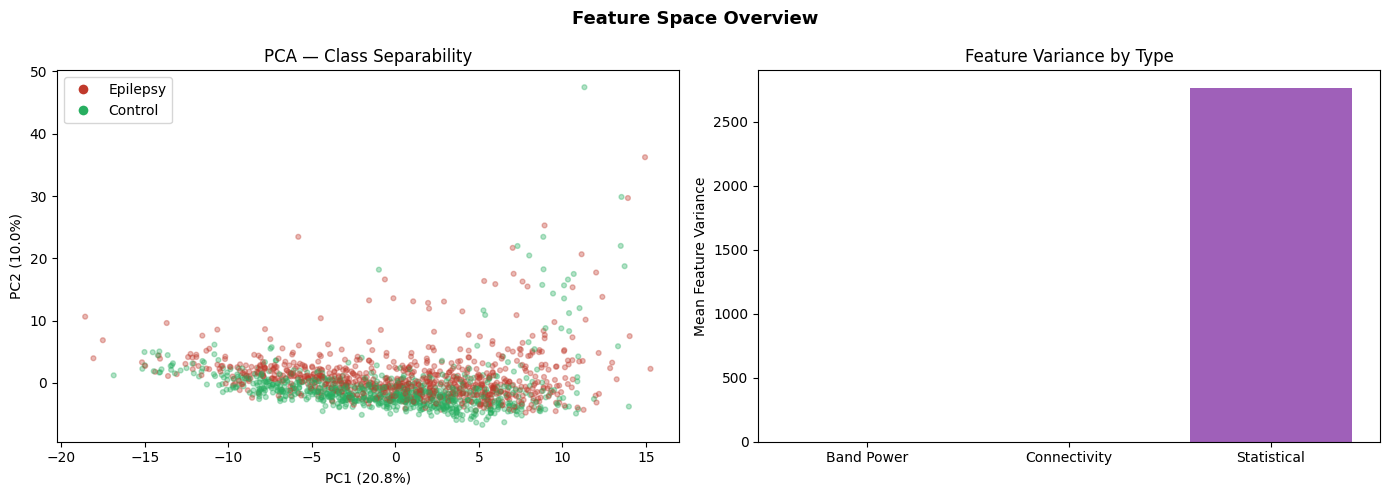

PCA variance (3 PCs): 35.8%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── PCA separability ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

X_sc  = StandardScaler().fit_transform(X)
pca   = PCA(n_components=3)
X_pca = pca.fit_transform(X_sc)

colors = ['#C0392B' if yi==0 else '#27AE60' for yi in y]
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.35, s=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — Class Separability')
axes[0].legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#C0392B',
           markersize=8,label='Epilepsy'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#27AE60',
           markersize=8,label='Control')
])

# ── Feature type importance preview (variance per type) ───────────────────────
types = ['Band Power'   if f.startswith('bp_')
         else 'Statistical' if f.startswith('stat_') or f.startswith('hjorth_')
         else 'Connectivity'
         for f in feat_names]
type_var = pd.DataFrame({'feature': feat_names, 'type': types,
                           'variance': X.var(axis=0)})\
             .groupby('type')['variance'].mean()

axes[1].bar(type_var.index, type_var.values,
            color=['#3498DB','#E74C3C','#8E44AD'], alpha=0.85)
axes[1].set_ylabel('Mean Feature Variance')
axes[1].set_title('Feature Variance by Type')

plt.suptitle('Feature Space Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_space.png', dpi=150)
plt.show()
print(f'PCA variance (3 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%')

## 🏗️ Step 6 — Define All 8 Classifiers

Every pipeline: `SMOTE → RobustScaler → Classifier`

In [10]:
def make_pipelines():
    smote = SMOTE(random_state=SEED, k_neighbors=5)

    # Scale-pos-weight for XGBoost
    spw = float((y==0).sum()) / float((y==1).sum())

    return {
        'Logistic Regression': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', LogisticRegression(
                C=1.0, max_iter=2000, class_weight='balanced',
                solver='saga', random_state=SEED))
        ]),
        'Ridge Classifier': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', RidgeClassifier(alpha=1.0, class_weight='balanced'))
        ]),
        'SVM (RBF)': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                        probability=True, class_weight='balanced',
                        random_state=SEED))
        ]),
        'Random Forest': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', RandomForestClassifier(
                n_estimators=500, class_weight='balanced',
                max_features='sqrt', min_samples_leaf=2,
                n_jobs=-1, random_state=SEED))
        ]),
        'Extra Trees': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', ExtraTreesClassifier(
                n_estimators=500, class_weight='balanced',
                max_features='sqrt', min_samples_leaf=2,
                n_jobs=-1, random_state=SEED))
        ]),
        'Gradient Boosting': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.05,
                max_depth=4, subsample=0.8, random_state=SEED))
        ]),
        'XGBoost': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', XGBClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=4,
                subsample=0.8, colsample_bytree=0.8,
                use_label_encoder=False, eval_metric='logloss',
                scale_pos_weight=spw, random_state=SEED, n_jobs=-1))
        ]),
        'Voting Ensemble': ImbPipeline([
            ('resample', smote), ('scaler', RobustScaler()),
            ('clf', VotingClassifier(
                estimators=[
                    ('rf',  RandomForestClassifier(
                        n_estimators=300, class_weight='balanced',
                        n_jobs=-1, random_state=SEED)),
                    ('svm', SVC(kernel='rbf', probability=True,
                                class_weight='balanced', random_state=SEED)),
                    ('xgb', XGBClassifier(
                        n_estimators=200, learning_rate=0.05, max_depth=4,
                        use_label_encoder=False, eval_metric='logloss',
                        scale_pos_weight=spw, random_state=SEED))
                ], voting='soft', n_jobs=-1))
        ]),
    }

clfs = make_pipelines()
print(f'✅ {len(clfs)} pipelines ready:')
for name in clfs: print(f'   • {name}')

✅ 8 pipelines ready:
   • Logistic Regression
   • Ridge Classifier
   • SVM (RBF)
   • Random Forest
   • Extra Trees
   • Gradient Boosting
   • XGBoost
   • Voting Ensemble


## 🏁 Step 7 — Benchmark All Models (GroupKFold CV)

**5-fold GroupKFold** — subjects never appear in both train and test.

In [11]:
def benchmark_all(clfs, X, y, groups, n_splits=5):
    gkf     = GroupKFold(n_splits=n_splits)
    scoring = {
        'accuracy':          'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'roc_auc':           'roc_auc',
        'f1_macro':          'f1_macro',
        'precision_macro':   'precision_macro',
        'recall_macro':      'recall_macro',
    }
    rows, raw = [], {}

    print(f'Benchmarking {len(clfs)} models — 5-fold GroupKFold...')
    print(f'{"Model":<22} {"Bal.Acc":>8} {"AUC":>8} '
          f'{"F1":>8} {"Recall":>8} {"Time":>7}')
    print('─' * 65)

    for name, pipe in clfs.items():
        t0 = time.time()
        cv = cross_validate(
            pipe, X, y, groups=groups,
            cv=gkf, scoring=scoring,
            return_estimator=True, n_jobs=-1)
        elapsed = time.time() - t0

        row = {'Model': name, 'Time_s': round(elapsed,1)}
        for m in scoring:
            s = cv[f'test_{m}']
            row[m]          = round(float(np.mean(s)), 4)
            row[f'{m}_std'] = round(float(np.std(s)),  4)
        rows.append(row)
        raw[name] = cv

        print(f'{name:<22} {row["balanced_accuracy"]:>8.4f} '
              f'{row["roc_auc"]:>8.4f} '
              f'{row["f1_macro"]:>8.4f} '
              f'{row["recall_macro"]:>8.4f} '
              f'{elapsed:>6.0f}s')

    df = pd.DataFrame(rows)\
           .sort_values('balanced_accuracy', ascending=False)\
           .reset_index(drop=True)
    return df, raw

results_df, raw_cv = benchmark_all(clfs, X, y, groups)

print('\n══ FULL RESULTS ═══════════════════════════════════════════════')
print(results_df[['Model','balanced_accuracy','roc_auc',
                   'f1_macro','recall_macro','Time_s']]\
      .to_string(index=False))
best_model_name = results_df.iloc[0]['Model']
print(f'\n🏆 Best: {best_model_name} '
      f'(bal_acc={results_df.iloc[0]["balanced_accuracy"]:.4f}, '
      f'AUC={results_df.iloc[0]["roc_auc"]:.4f})')

Benchmarking 8 models — 5-fold GroupKFold...
Model                   Bal.Acc      AUC       F1   Recall    Time
─────────────────────────────────────────────────────────────────
Logistic Regression      0.7299   0.7856   0.7083   0.7299     59s
Ridge Classifier         0.7313   0.7855   0.7112   0.7313      0s
SVM (RBF)                0.7506   0.8251   0.7311   0.7506      5s
Random Forest            0.7623   0.8428   0.7394   0.7623     61s
Extra Trees              0.7633   0.8433   0.7411   0.7633     11s
Gradient Boosting        0.7647   0.8301   0.7427   0.7647    105s
XGBoost                  0.7672   0.8351   0.7452   0.7672     18s
Voting Ensemble          0.7716   0.8426   0.7511   0.7716     47s

══ FULL RESULTS ═══════════════════════════════════════════════
              Model  balanced_accuracy  roc_auc  f1_macro  recall_macro  Time_s
    Voting Ensemble             0.7716   0.8426    0.7511        0.7716    47.4
            XGBoost             0.7672   0.8351    0.7452    

## 📊 Step 8 — Benchmark Visualisation

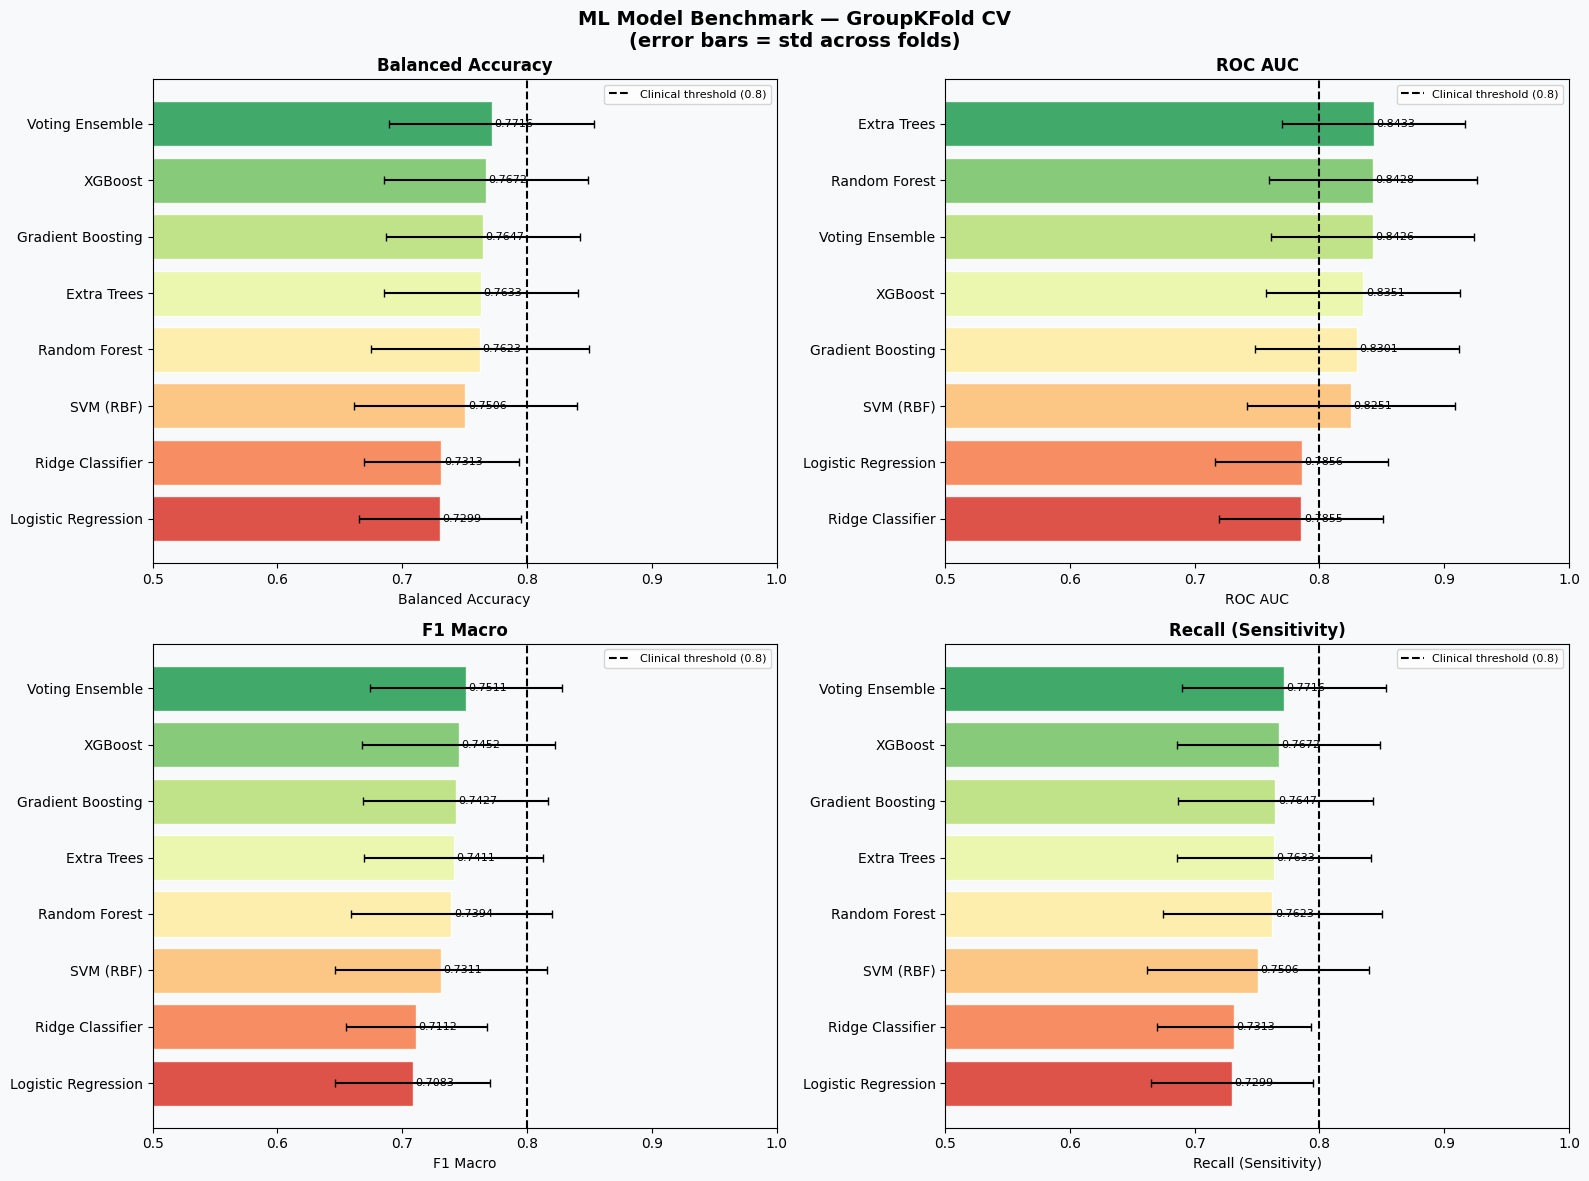

Saved: benchmark_comparison.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
metrics_list = ['balanced_accuracy','roc_auc','f1_macro','recall_macro']
titles       = ['Balanced Accuracy','ROC AUC','F1 Macro','Recall (Sensitivity)']

for ax, metric, title in zip(axes.flatten(), metrics_list, titles):
    df_s    = results_df.sort_values(metric, ascending=True)
    palette = sns.color_palette('RdYlGn', len(df_s))
    std_col = f'{metric}_std'

    bars = ax.barh(
        df_s['Model'], df_s[metric],
        xerr=df_s[std_col] if std_col in df_s.columns else None,
        color=palette, alpha=0.85, edgecolor='white', capsize=3)
    ax.axvline(0.8, color='black', linestyle='--',
               lw=1.5, label='Clinical threshold (0.8)')
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel(title)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_facecolor('#F8F9FA')
    for bar, val in zip(bars, df_s[metric]):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('ML Model Benchmark — GroupKFold CV\n(error bars = std across folds)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison.png')

## 📉 Step 9 — ROC & Precision-Recall Curves (All Models)

Computing OOF predictions...
  ✅ Logistic Regression
  ⚠  Ridge Classifier: This 'Pipeline' has no attribute 'predict_proba'
  ✅ SVM (RBF)
  ✅ Random Forest
  ✅ Extra Trees
  ✅ Gradient Boosting
  ✅ XGBoost
  ✅ Voting Ensemble


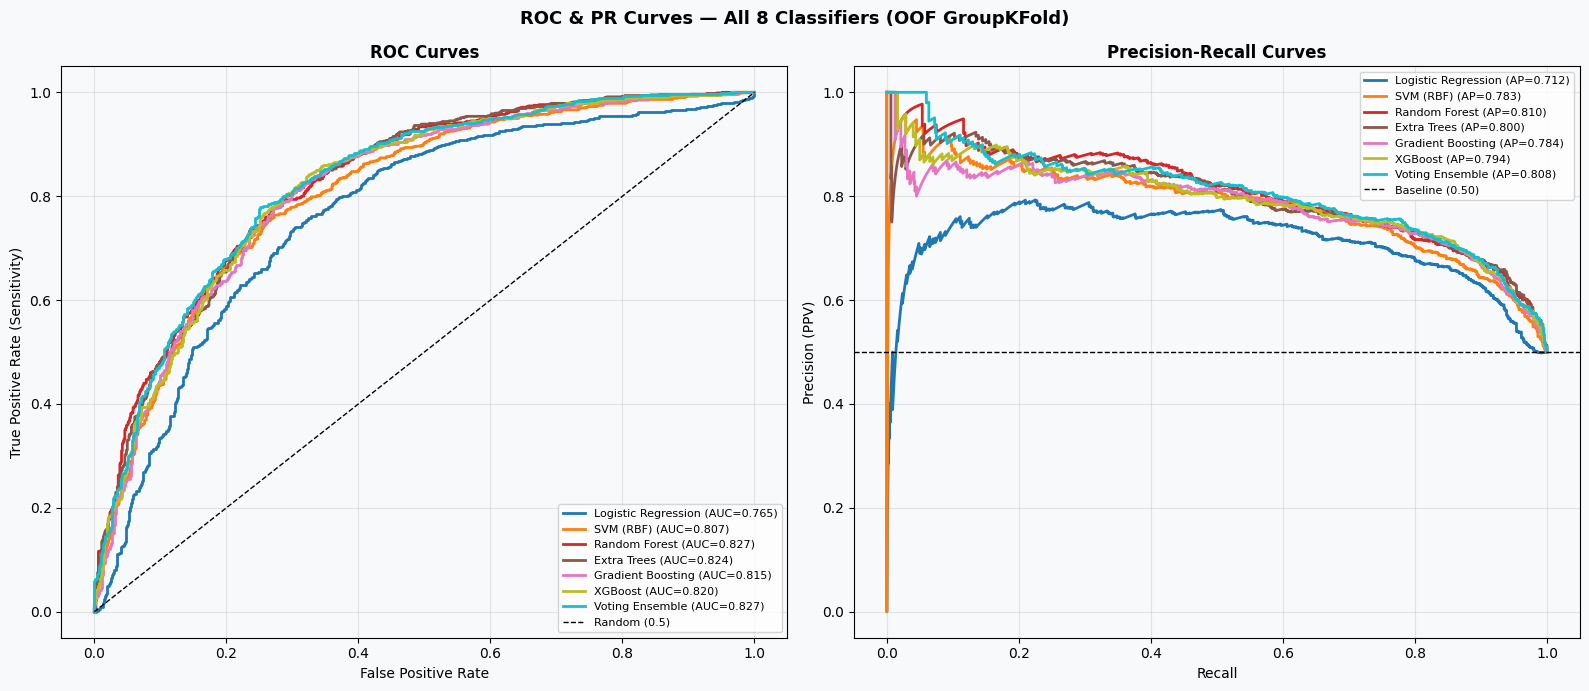

Saved: roc_pr_curves.png


In [13]:
gkf = GroupKFold(n_splits=5)
oof_probs = {}
print('Computing OOF predictions...')
for name, pipe in clfs.items():
    try:
        probs = cross_val_predict(
            pipe, X, y, groups=groups,
            cv=gkf, method='predict_proba', n_jobs=-1)
        oof_probs[name] = probs[:, 1]
        print(f'  ✅ {name}')
    except Exception as e:
        print(f'  ⚠  {name}: {e}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')
palette = plt.cm.tab10(np.linspace(0, 1, len(oof_probs)))

for ax, curve_type in zip(axes, ['roc', 'pr']):
    for (name, probs), color in zip(oof_probs.items(), palette):
        if curve_type == 'roc':
            fpr, tpr, _ = roc_curve(y, probs)
            auc = roc_auc_score(y, probs)
            ax.plot(fpr, tpr, lw=2, color=color,
                    label=f'{name} (AUC={auc:.3f})')
        else:
            prec, rec, _ = precision_recall_curve(y, probs)
            ap = average_precision_score(y, probs)
            ax.plot(rec, prec, lw=2, color=color,
                    label=f'{name} (AP={ap:.3f})')

    if curve_type == 'roc':
        ax.plot([0,1],[0,1],'k--',lw=1,label='Random (0.5)')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate (Sensitivity)')
        ax.set_title('ROC Curves', fontweight='bold')
    else:
        ax.axhline(y.mean(), color='k', linestyle='--', lw=1,
                   label=f'Baseline ({y.mean():.2f})')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision (PPV)')
        ax.set_title('Precision-Recall Curves', fontweight='bold')

    ax.legend(fontsize=8, loc='lower right' if curve_type=='roc'
              else 'upper right')
    ax.grid(alpha=0.3)
    ax.set_facecolor('#F8F9FA')

plt.suptitle('ROC & PR Curves — All 8 Classifiers (OOF GroupKFold)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves.png')

## 🎯 Step 10 — Confusion Matrices (All Models)

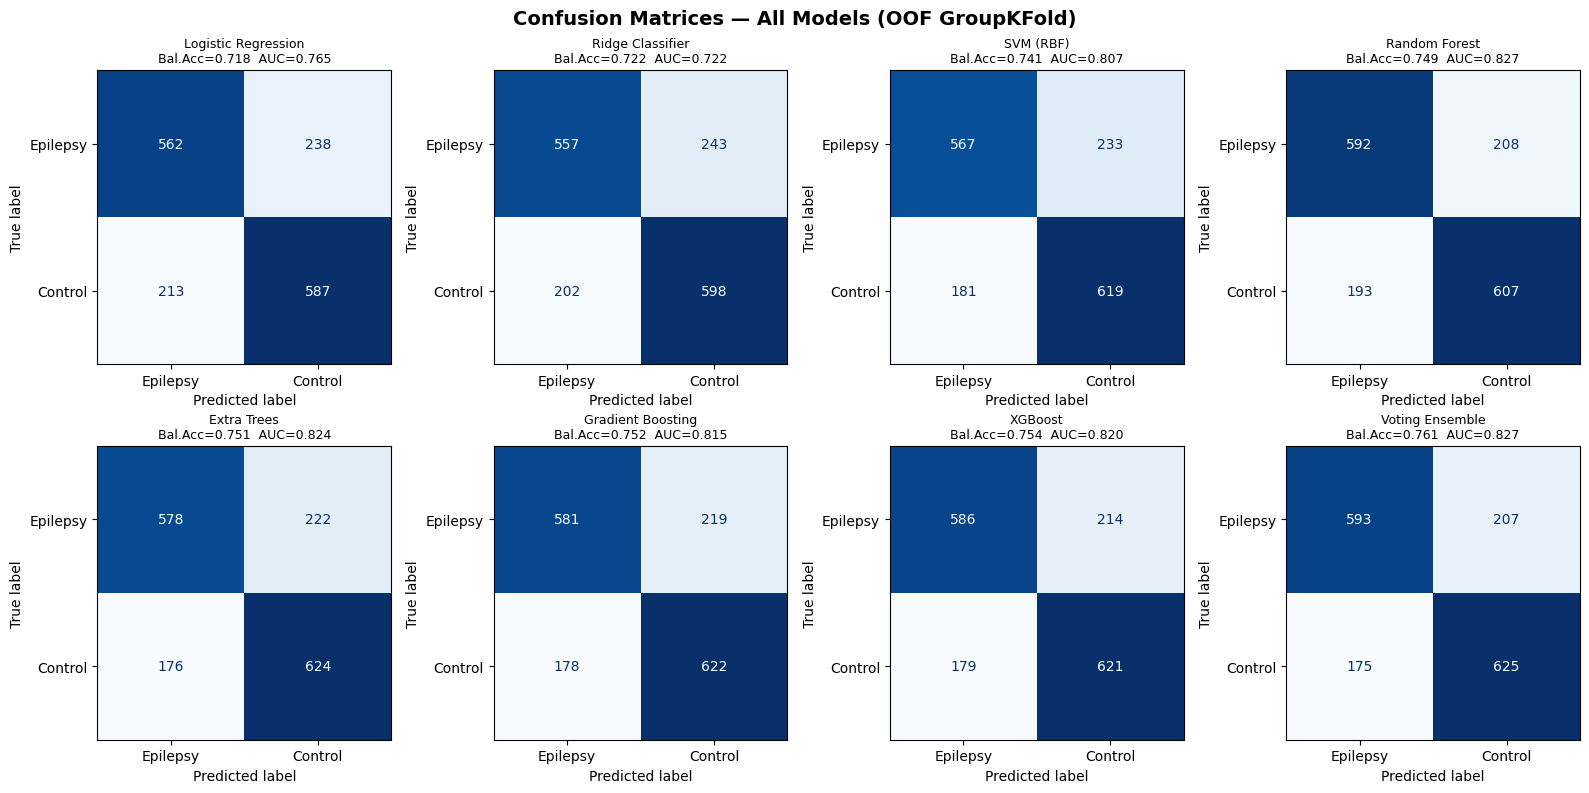

Saved: confusion_matrices_all.png


In [14]:
y_preds = {}
for name, pipe in clfs.items():
    y_preds[name] = cross_val_predict(
        pipe, X, y, groups=groups, cv=gkf, n_jobs=-1)

n_models = len(y_preds)
ncols    = 4
nrows    = (n_models + ncols-1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, y_preds.items()):
    cm   = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Epilepsy','Control'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ba  = balanced_accuracy_score(y, y_pred)
    auc = roc_auc_score(y, oof_probs.get(name, y_pred))
    ax.set_title(f'{name}\nBal.Acc={ba:.3f}  AUC={auc:.3f}', fontsize=9)

for ax in axes[n_models:]: ax.set_visible(False)
plt.suptitle('Confusion Matrices — All Models (OOF GroupKFold)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all.png')

## 🎛️ Step 11 — Hyperparameter Tuning (Best Model)

GridSearchCV on the best model with inner GroupKFold to avoid leakage.

In [15]:
PARAM_GRIDS = {
    'Random Forest':     {'clf__n_estimators':[300,500],
                           'clf__max_depth':[None,15,25],
                           'clf__min_samples_leaf':[1,2,4]},
    'Extra Trees':       {'clf__n_estimators':[300,500],
                           'clf__min_samples_leaf':[1,2,4]},
    'SVM (RBF)':         {'clf__C':[0.1,1.0,10.0],
                           'clf__gamma':['scale','auto',0.01]},
    'XGBoost':           {'clf__n_estimators':[200,300],
                           'clf__learning_rate':[0.03,0.05,0.1],
                           'clf__max_depth':[3,4,6]},
    'Logistic Regression':{'clf__C':[0.01,0.1,1.0,10.0]},
    'Gradient Boosting': {'clf__n_estimators':[100,200],
                           'clf__learning_rate':[0.03,0.05,0.1]},
    'Ridge Classifier':  {'clf__alpha':[0.1,1.0,10.0,100.0]},
    'Voting Ensemble':   {},
}

param_grid = PARAM_GRIDS.get(best_model_name, {})
print(f'Tuning: {best_model_name}')
print(f'Param grid: {param_grid}')

if param_grid:
    grid_search = GridSearchCV(
        clfs[best_model_name], param_grid,
        cv=GroupKFold(n_splits=3),
        scoring='balanced_accuracy',
        n_jobs=-1, verbose=1, refit=True)
    grid_search.fit(X, y, groups=groups)
    print(f'\nBest params:   {grid_search.best_params_}')
    print(f'Best CV score: {grid_search.best_score_:.4f}')
    tuned_pipe = grid_search.best_estimator_
else:
    print('No grid defined — using default pipeline.')
    tuned_pipe = clfs[best_model_name]
    tuned_pipe.fit(X, y)

Tuning: Voting Ensemble
Param grid: {}
No grid defined — using default pipeline.


## 🔍 Step 12 — Feature Importance

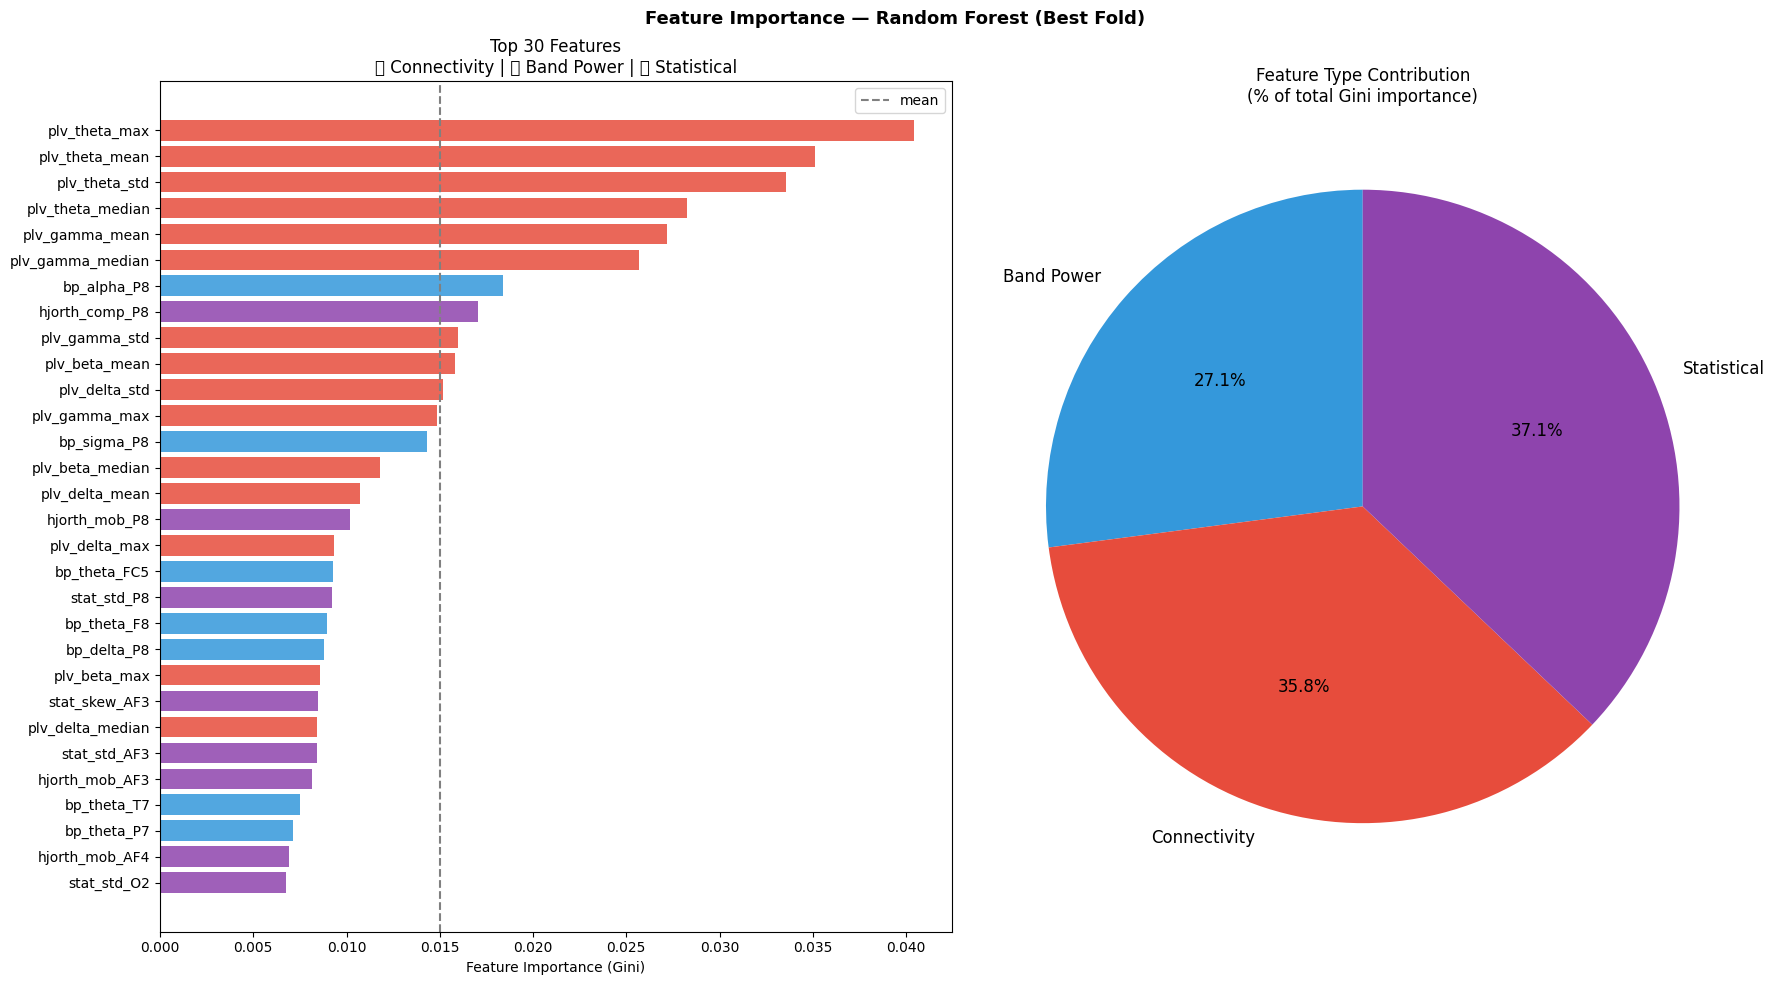

In [16]:
# Use Random Forest for importance (always available)
rf_cv     = raw_cv['Random Forest']
best_fold = int(np.argmax(rf_cv['test_balanced_accuracy']))
rf_pipe   = rf_cv['estimator'][best_fold]
clf_step  = rf_pipe.named_steps['clf']

importances = clf_step.feature_importances_
imp_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': importances,
    'type':       ['Band Power'  if f.startswith('bp_')
                   else 'Statistical' if f.startswith('stat_') or f.startswith('hjorth_')
                   else 'Connectivity'
                   for f in feat_names]
}).sort_values('importance', ascending=False).reset_index(drop=True)

top = imp_df.head(30)
pal = {'Band Power':'#3498DB','Statistical':'#8E44AD','Connectivity':'#E74C3C'}
colors_bars = [pal[t] for t in top['type']]

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(top['feature'][::-1], top['importance'][::-1],
             color=colors_bars[::-1], alpha=0.85)
axes[0].axvline(top['importance'].mean(), color='grey',
                linestyle='--', lw=1.5, label='mean')
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Top 30 Features\n'
                  '🔴 Connectivity | 🔵 Band Power | 🟣 Statistical')
axes[0].legend()

type_imp = imp_df.groupby('type')['importance'].sum()
axes[1].pie(type_imp.values, labels=type_imp.index,
            colors=[pal[t] for t in type_imp.index],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12})
axes[1].set_title('Feature Type Contribution\n(% of total Gini importance)')

plt.suptitle('Feature Importance — Random Forest (Best Fold)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_ml.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Step 13 — SHAP Explainability

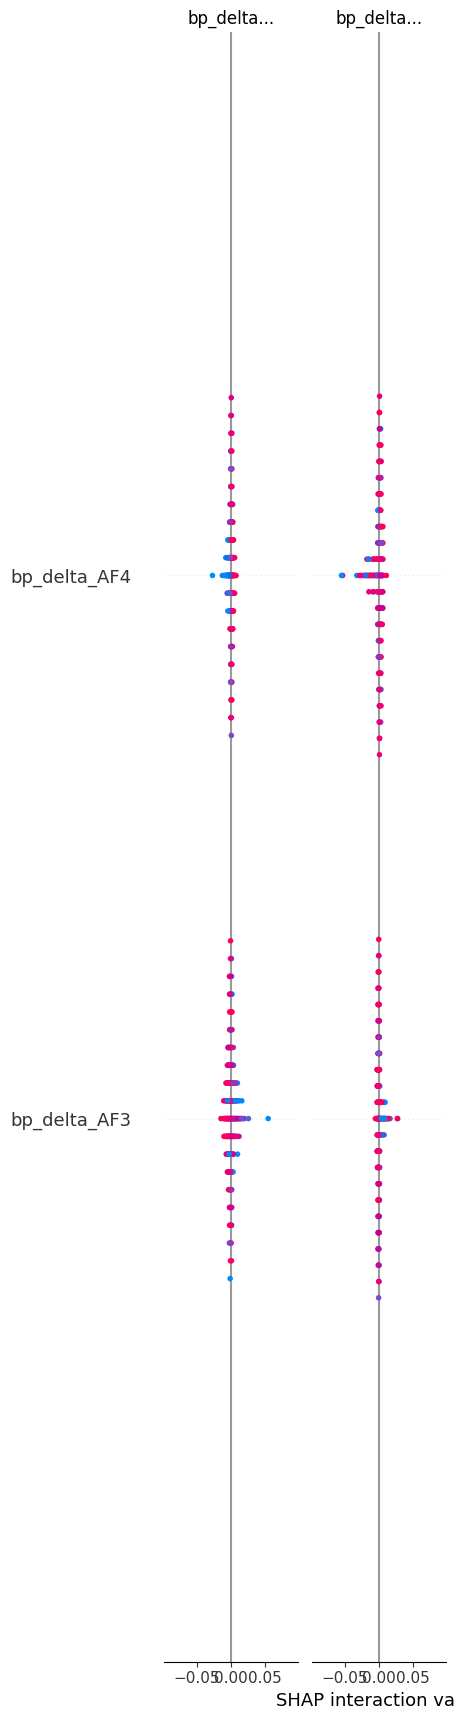

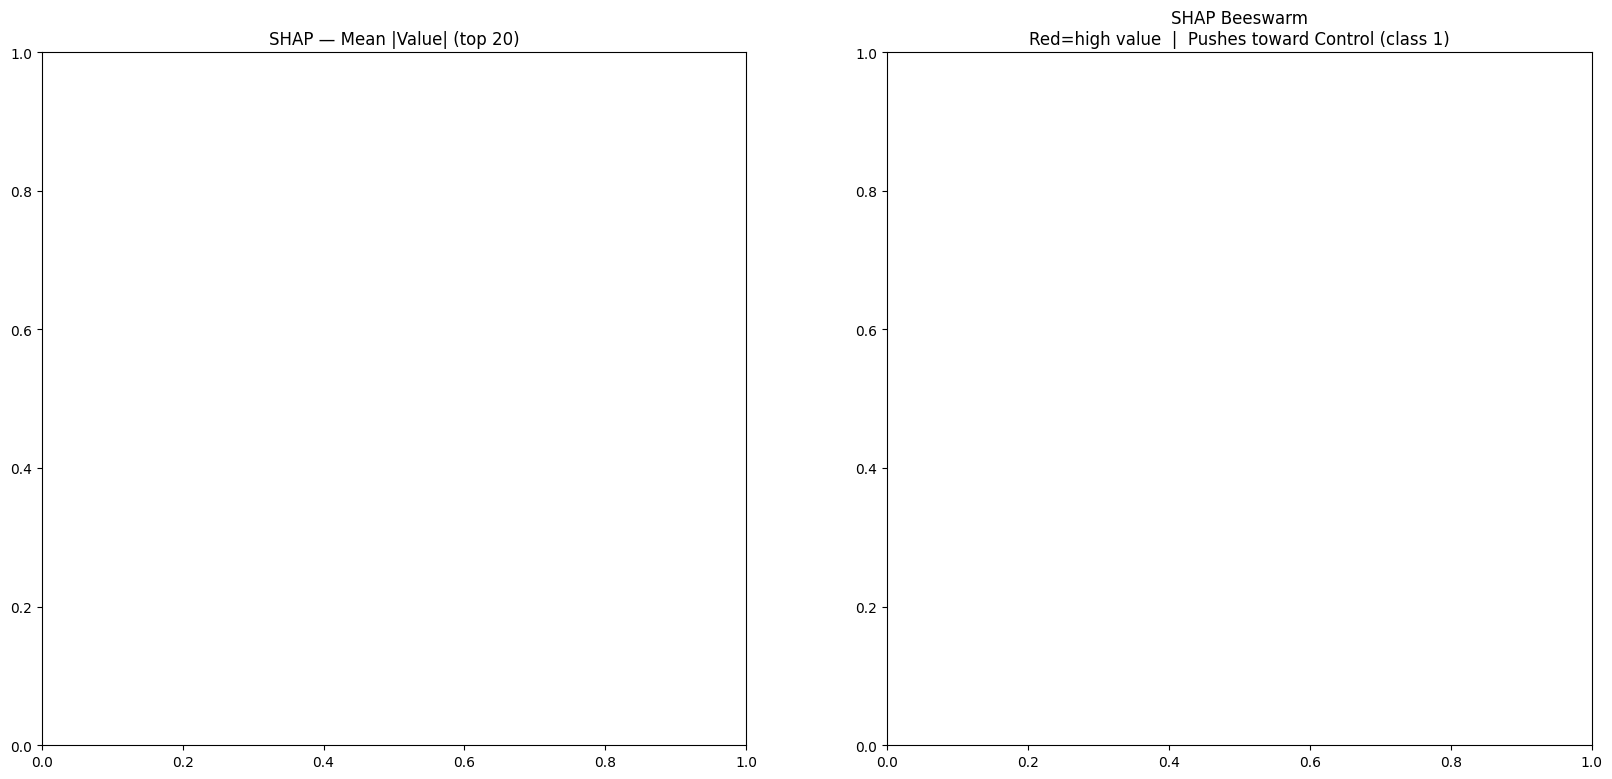

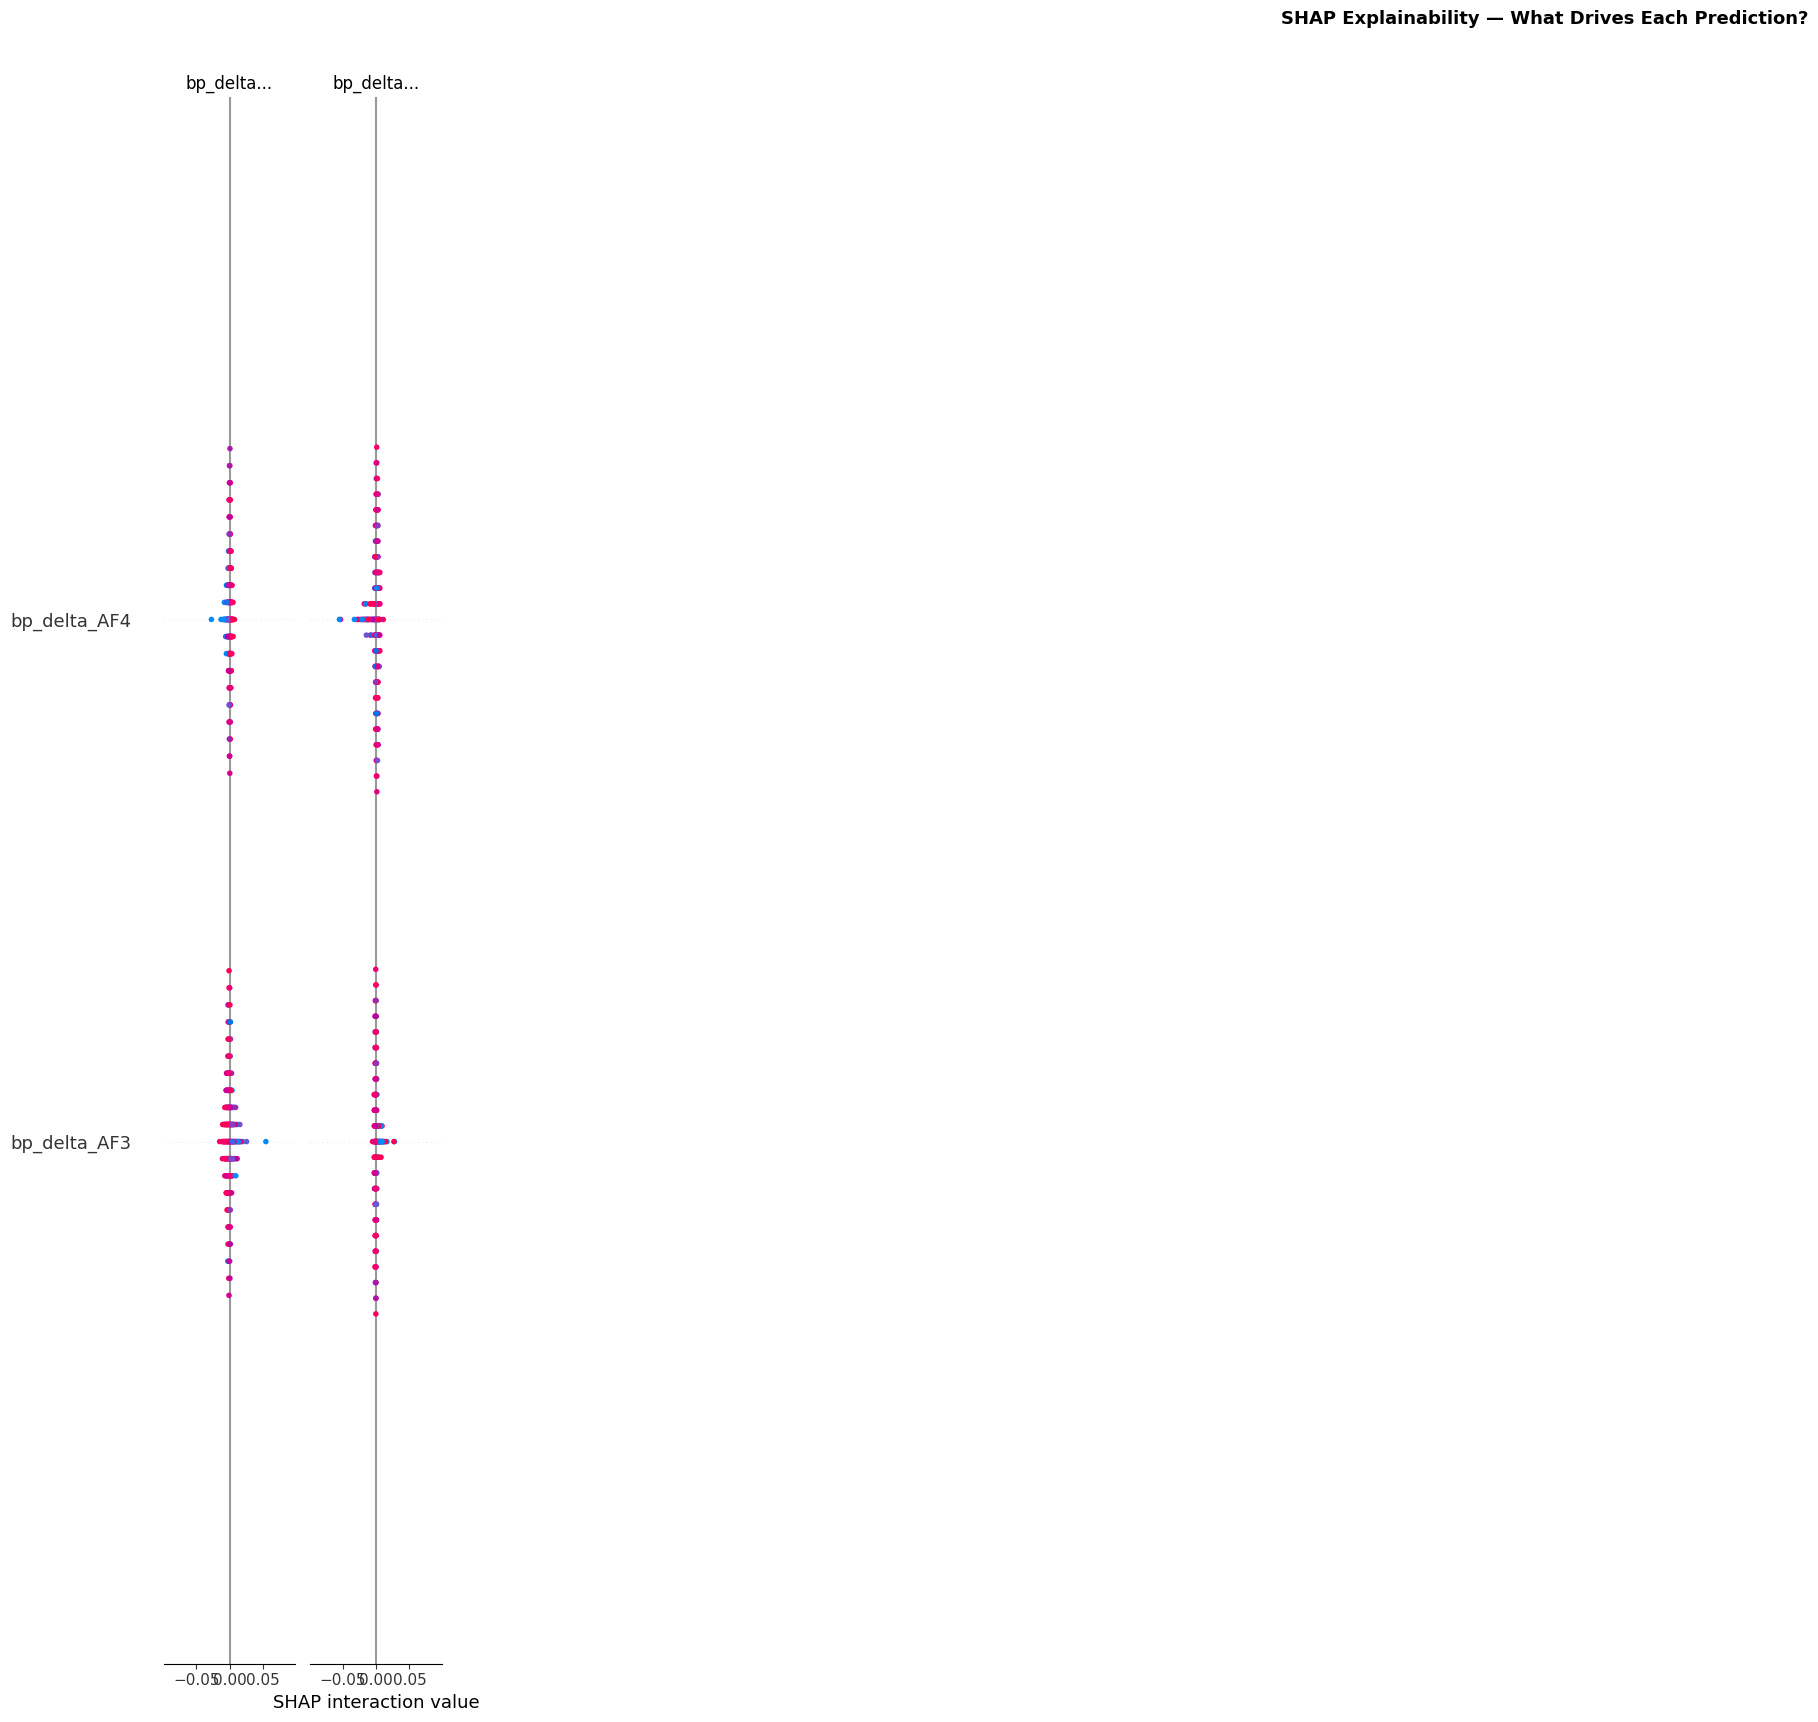

Saved: shap_analysis.png


In [17]:
if SHAP_OK:
    # Refit RF without SMOTE on scaled data for cleaner SHAP
    from sklearn.preprocessing import RobustScaler
    scaler_shap = RobustScaler()
    X_shap      = scaler_shap.fit_transform(X)
    rf_shap     = RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=SEED)
    rf_shap.fit(X_shap, y)

    sample = shap.sample(X_shap, 200, random_state=SEED)
    explainer = shap.TreeExplainer(rf_shap)
    shap_vals = explainer.shap_values(sample)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    plt.sca(axes[0])
    shap.summary_plot(sv, sample, feature_names=feat_names,
                      max_display=20, show=False, plot_type='bar')
    axes[0].set_title('SHAP — Mean |Value| (top 20)', fontsize=12)

    plt.sca(axes[1])
    shap.summary_plot(sv, sample, feature_names=feat_names,
                      max_display=20, show=False)
    axes[1].set_title(
        'SHAP Beeswarm\nRed=high value  |  Pushes toward Control (class 1)',
        fontsize=12)

    plt.suptitle('SHAP Explainability — What Drives Each Prediction?',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: shap_analysis.png')
else:
    print('Run: !pip install shap  then restart kernel')

## 🔄 Step 14 — Nested CV (Unbiased Estimate)

Outer GroupKFold(5) × Inner GroupKFold(3).  
Gives an honest estimate that is not optimistically biased by hyperparameter selection.

In [18]:
def nested_cv(model_name, pipe, param_grid, X, y, groups,
              outer=5, inner=3):
    outer_cv = GroupKFold(n_splits=outer)
    inner_cv = GroupKFold(n_splits=inner)
    scores   = []

    for fold, (tr, te) in enumerate(
            outer_cv.split(X, y, groups)):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        g_tr       = groups[tr]

        if param_grid:
            gs = GridSearchCV(pipe, param_grid,
                               cv=inner_cv,
                               scoring='balanced_accuracy',
                               n_jobs=-1)
            gs.fit(X_tr, y_tr, groups=g_tr)
            best = gs.best_estimator_
        else:
            pipe.fit(X_tr, y_tr)
            best = pipe

        y_pred = best.predict(X_te)
        scores.append(balanced_accuracy_score(y_te, y_pred))
        print(f'  Fold {fold+1}: {scores[-1]:.4f}')

    mean_s = np.mean(scores)
    std_s  = np.std(scores)
    print(f'  Nested CV: {mean_s:.4f} ± {std_s:.4f}')
    return scores

# Run on top 2 models only
top2 = results_df.head(2)['Model'].tolist()
nested_scores = {}

for mname in top2:
    print(f'\nNested CV — {mname}:')
    pg = PARAM_GRIDS.get(mname, {})
    nested_scores[mname] = nested_cv(
        mname, clfs[mname], pg, X, y, groups)

print('\n── Optimism Bias Check ───────────────────────────────────────────')
for mname, scores in nested_scores.items():
    standard = float(results_df[
        results_df['Model']==mname]['balanced_accuracy'].values[0])
    nested   = float(np.mean(scores))
    bias     = standard - nested
    print(f'  {mname:<22}: standard={standard:.4f}  '
          f'nested={nested:.4f}  bias={bias:+.4f}')


Nested CV — Voting Ensemble:
  Fold 1: 0.6160
  Fold 2: 0.7738
  Fold 3: 0.8529
  Fold 4: 0.8000
  Fold 5: 0.8152
  Nested CV: 0.7716 ± 0.0819

Nested CV — XGBoost:
  Fold 1: 0.6318
  Fold 2: 0.7423
  Fold 3: 0.8582
  Fold 4: 0.7689
  Fold 5: 0.7869
  Nested CV: 0.7576 ± 0.0737

── Optimism Bias Check ───────────────────────────────────────────
  Voting Ensemble       : standard=0.7716  nested=0.7716  bias=+0.0000
  XGBoost               : standard=0.7672  nested=0.7576  bias=+0.0096


## 💾 Step 15 — Train & Save Final Model

In [19]:
print(f'Training final model: {best_model_name}')
final_model = tuned_pipe
final_model.fit(X, y)

joblib.dump(final_model, 'final_eeg_classifier.pkl')
with open('feature_names.json', 'w') as f:
    json.dump(feat_names, f)

print('✅ Saved: final_eeg_classifier.pkl')
print('✅ Saved: feature_names.json')

# Quick sanity check
test_proba = final_model.predict_proba(X[:5])[:,1]
test_pred  = final_model.predict(X[:5])
print('\nSanity check (first 5 epochs):')
for i,(pred,prob) in enumerate(zip(test_pred, test_proba)):
    true_name = 'Epilepsy' if y[i]==0 else 'Control'
    pred_name = 'Epilepsy' if pred==0 else 'Control'
    ok = '✅' if pred==y[i] else '❌'
    print(f'  [{ok}] True={true_name:<10} '
          f'Pred={pred_name:<10} P(Control)={prob:.3f}')

Training final model: Voting Ensemble
✅ Saved: final_eeg_classifier.pkl
✅ Saved: feature_names.json

Sanity check (first 5 epochs):
  [✅] True=Epilepsy   Pred=Epilepsy   P(Control)=0.026
  [✅] True=Epilepsy   Pred=Epilepsy   P(Control)=0.444
  [✅] True=Epilepsy   Pred=Epilepsy   P(Control)=0.320
  [✅] True=Epilepsy   Pred=Epilepsy   P(Control)=0.070
  [✅] True=Control    Pred=Control    P(Control)=0.958


## 🚀 Step 16 — Inference on New Patient

In [20]:
def predict_new_patient(raw_mne_epochs,
                         model_path='final_eeg_classifier.pkl',
                         feat_names_path='feature_names.json',
                         threshold=0.5):
    """
    Run trained model on new patient MNE epochs.

    Parameters
    ----------
    raw_mne_epochs : mne.Epochs  (pre-filtered, 14 channels)

    Returns
    -------
    result : dict  with patient-level decision + probabilities
    """
    model          = joblib.load(model_path)
    expected_feats = json.load(open(feat_names_path))

    # Feature extraction (same as training)
    Xb, nb = extract_band_power(raw_mne_epochs)
    Xs, ns = extract_stats(raw_mne_epochs)
    Xc, nc = extract_connectivity(raw_mne_epochs)
    X_new  = np.hstack([Xb, Xs, Xc]).astype(np.float32)
    X_new  = np.nan_to_num(X_new)

    # Align to trained feature names
    feat_map  = {f: i for i, f in enumerate(nb + ns + nc)}
    X_aligned = np.zeros((len(X_new), len(expected_feats)))
    for j, fname in enumerate(expected_feats):
        if fname in feat_map:
            X_aligned[:, j] = X_new[:, feat_map[fname]]

    # Epoch-level probabilities
    try:
        epoch_probs = model.predict_proba(X_aligned)[:, 1]  # P(Control)
    except AttributeError:
        epoch_probs = (model.predict(X_aligned) == 1).astype(float)

    epi_prob = float(1 - epoch_probs.mean())  # P(Epilepsy)

    if   epi_prob > threshold + 0.15: decision, risk = 'EPILEPSY',  'HIGH'
    elif epi_prob > threshold:         decision, risk = 'EPILEPSY',  'MODERATE'
    elif epi_prob < threshold - 0.15: decision, risk = 'CONTROL',   'LOW'
    else:                              decision, risk = 'UNCERTAIN', 'REVIEW'

    result = {
        'n_epochs':       int(len(raw_mne_epochs)),
        'P_epilepsy':     round(epi_prob, 4),
        'P_control':      round(1 - epi_prob, 4),
        'decision':       decision,
        'risk_level':     risk,
        'epoch_vote_pct': round(float((1-epoch_probs >= threshold).mean()*100), 1),
        'disclaimer':     'Research only. Requires neurologist review.'
    }
    print(json.dumps(result, indent=2))
    return result

# Test on sample patient
print('Testing inference on 30 sample epochs...')
predict_new_patient(epochs_ml[:30])

Testing inference on 30 sample epochs...
Effective window size : 5.000 (s)
  Connectivity 0/30
{
  "n_epochs": 30,
  "P_epilepsy": 0.5263,
  "P_control": 0.4737,
  "decision": "EPILEPSY",
  "risk_level": "MODERATE",
  "epoch_vote_pct": 56.7,
  "disclaimer": "Research only. Requires neurologist review."
}


{'n_epochs': 30,
 'P_epilepsy': 0.5263,
 'P_control': 0.4737,
 'decision': 'EPILEPSY',
 'risk_level': 'MODERATE',
 'epoch_vote_pct': 56.7,
 'disclaimer': 'Research only. Requires neurologist review.'}

## 📋 Step 17 — Final Summary

In [21]:
print('═══ PURE ML PIPELINE — FINAL SUMMARY ══════════════════════════════')
print(f'  Working set:   {len(X)} epochs, {len(np.unique(groups))} subjects')
print(f'  Features:      {X.shape[1]} total  '
      f'(band power + statistical + connectivity)')
print()
print('  Benchmark Results (GroupKFold, balanced_accuracy):')
print(f'  {"Model":<22} {"Bal.Acc":>10} {"AUC":>10}')
print('  ' + '─'*45)
for _, row in results_df.iterrows():
    marker = ' ← BEST' if _ == 0 else ''
    print(f'  {row["Model"]:<22} '
          f'{row["balanced_accuracy"]:>10.4f} '
          f'{row["roc_auc"]:>10.4f}{marker}')
print()
print(f'  Best model:    {best_model_name}')
print()
print('  Saved files:')
for fname in ['benchmark_comparison.png', 'roc_pr_curves.png',
              'confusion_matrices_all.png', 'feature_importance_ml.png',
              'shap_analysis.png', 'final_eeg_classifier.pkl',
              'feature_names.json']:
    print(f'    {fname}')

═══ PURE ML PIPELINE — FINAL SUMMARY ══════════════════════════════
  Working set:   1600 epochs, 97 subjects
  Features:      169 total  (band power + statistical + connectivity)

  Benchmark Results (GroupKFold, balanced_accuracy):
  Model                     Bal.Acc        AUC
  ─────────────────────────────────────────────
  Voting Ensemble            0.7716     0.8426 ← BEST
  XGBoost                    0.7672     0.8351
  Gradient Boosting          0.7647     0.8301
  Extra Trees                0.7633     0.8433
  Random Forest              0.7623     0.8428
  SVM (RBF)                  0.7506     0.8251
  Ridge Classifier           0.7313     0.7855
  Logistic Regression        0.7299     0.7856

  Best model:    Voting Ensemble

  Saved files:
    benchmark_comparison.png
    roc_pr_curves.png
    confusion_matrices_all.png
    feature_importance_ml.png
    shap_analysis.png
    final_eeg_classifier.pkl
    feature_names.json


## ✅ Quick Reference

| Step | What it does |
|---|---|
| 2 | **Always run** — loads `data`, `label`, `group` |
| 3 | Creates balanced working set (`y`, `groups`, `epochs_ml`) |
| 4 | Extracts 198 features into matrix `X` |
| 6 | Defines 8 classifier pipelines (`clfs`) |
| 7 | Benchmarks all 8 → `results_df`, `raw_cv` |
| 9 | OOF ROC + PR curves → `oof_probs` |
| 11 | Tunes best model → `tuned_pipe` |
| 14 | Nested CV → unbiased estimate |
| 15 | Saves `final_eeg_classifier.pkl` |
| 16 | `predict_new_patient()` inference function |